## 01 - Análise Exploratória

---



---

### Importação de Pacotes e Funções Auxiliares

In [ ]:
import re
import math
import unicodedata
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
import geopandas as gpd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [324]:
output_dir = Path("../results")
fig_dir = output_dir / "figures/aedv"
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [325]:
def normalize_text(value, title=False):
    value = str(value).strip().lower()
    value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("utf-8")
    value = re.sub(r"\s+", " ", value)
    if title:
        value = value.title()
        value = " ".join([w.lower() if len(w) <= 3 else w for w in value.split()])
    return value

def remove_accent(texto):
    if isinstance(texto, str):
        return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto

def pretty_label(value):
    value = str(value).replace("_", " ").strip()
    value = str(value).replace("cao", "ção").strip()
    return value.title()

def format_number_ptbr(valor):
    return f"{valor:,.0f}".replace(",", ".")

def format_percentual_ptbr(valor):
    return f"{valor:.1f}%".replace(".", ",")

def save_figure(fig, name):
    path = fig_dir / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

def create_date_columns(df):
    df["month"] = df["data_abertura"].dt.to_period("M").dt.to_timestamp()
    df["month_label"] = df["month"].dt.strftime("%Y-%m")
    df["week"] = df["data_abertura"].dt.to_period("W").dt.to_timestamp()
    df["week_label"] = df["week"].dt.strftime("%Y-%m-%d")
    return df

### 1. Leitura, Validação e Tratamento de Dados

In [326]:
def load_and_prepare_data(path):
    df = pd.read_csv(path, dtype={"id_chamado": str})
    df["data_abertura"] = pd.to_datetime(df["data_abertura"], errors="coerce")
    df["texto"] = df["texto"].fillna("").astype(str).str.strip()
    df["bairro"] = df["bairro"].astype(str).str.strip()
    df["bairro"] = df["bairro"].map(normalize_text)
    df["canal"] = df["canal"].astype(str).str.strip()
    df["categoria_real"] = df["categoria_real"].astype(str).str.strip()
    df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
    df["pred_modelo_b"] = df["pred_modelo_b"].astype(str).str.strip()

    df["categoria_real_label"] = df["categoria_real"].map(pretty_label)
    df["canal_label"] = df["canal"].map(pretty_label)
    df["bairro_label"] = df["bairro"].map(pretty_label)
    df["texto_limpo"] = df["texto"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["tamanho_texto_palavras"] = df["texto"].str.replace(r"\s+", " ", regex=True).str.strip().str.split().str.len()
    df["palavra_count"] = df["texto"].str.split().str.len()
    df["bool_texto_curto"] = df["palavra_count"] <= 5

    df["correct_model_a"] = df["pred_modelo_a"].eq(df["categoria_real"])
    df["correct_model_b"] = df["pred_modelo_b"].eq(df["categoria_real"])

    df = create_date_columns(df)
    return  df

In [327]:
warnings.filterwarnings("ignore")
df = load_and_prepare_data('../dados/chamados_com_predicoes.csv')

#### 1.1 Visão Geral dos Dados

In [328]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

sanity_metrics = [
    ("Tamanho (linhas, colunas)", df.shape),
    ("IDs de chamados duplicados", df["id_chamado"].duplicated().sum()),
    ("IDs de chamados com menos de 10 caracteres", df["id_chamado"].fillna("").astype(str).str.len().lt(10).sum()),
    ("Valores faltantes/NaN", df.isna().sum().sum()),
    ("Média do tamanho do texto em palavras", round(df["palavra_count"].mean(), 2)),
    ("Mediana do tamanho do texto em palavras", round(df["palavra_count"].median(), 2)),
    ("Textos muito curtos (<= 5 palavras) (%)", round(100 * df["bool_texto_curto"].mean(), 2)),
]

general_metrics = [
    ("Data de início", df["data_abertura"].min()),
    ("Data de término", df["data_abertura"].max()),
    ("Número de categorias", df["categoria_real"].nunique()),
    ("Número de categorias previstas", f"Modelo A: {df['pred_modelo_a'].nunique()}, Modelo B: {df['pred_modelo_b'].nunique()}"),
    ("Número de bairros", df["bairro"].nunique()),
    ("Número de canais", df["canal"].nunique()),
]

sanity_table = pd.DataFrame(sanity_metrics, columns=["Métrica", "Valor"])
metrics_table = pd.DataFrame(general_metrics, columns=["Métrica", "Valor"])

type_table = (
    df.dtypes.astype(str)
    .groupby(df.dtypes.astype(str))
    .apply(lambda x: list(x.index))
    .reset_index(name="Colunas")
    .rename(columns={"index": "Tipo"})
)

display(sanity_table)
display(metrics_table)
display(type_table)

pd.reset_option("display.max_colwidth")
pd.reset_option("display.width")

,Métrica,Valor
0,"Tamanho (linhas, colunas)","(5000, 23)"
1,IDs de chamados duplicados,0
2,IDs de chamados com menos de 10 caracteres,0
3,Valores faltantes/NaN,0
4,Média do tamanho do texto em palavras,23.26
5,Mediana do tamanho do texto em palavras,28.0
6,Textos muito curtos (<= 5 palavras) (%),2.4


,Métrica,Valor
0,Data de início,2026-01-01 00:00:00
1,Data de término,2026-06-30 00:00:00
2,Número de categorias,8
3,Número de categorias previstas,"Modelo A: 8, Modelo B: 8"
4,Número de bairros,15
5,Número de canais,3


,Tipo,Colunas
0,bool,"[bool_texto_curto, correct_model_a, correct_model_b]"
1,datetime64[ns],"[data_abertura, month, week]"
2,float64,"[conf_modelo_a, conf_modelo_b]"
3,int64,"[tamanho_texto_palavras, palavra_count]"
4,object,"[id_chamado, bairro, canal, texto, categoria_real, pred_modelo_a, pred_modelo_b, categoria_real_label, canal_label, bairro_label, texto_limpo, month_label, week_label]"


### 2. Panorama Geral dos Chamados

#### 2.1 Distribuição de Chamados por Categoria, Bairro e Canal

In [329]:
def tabela_contagem_percentual(df, coluna, ordenar=True):
    tabela = df[coluna].value_counts(dropna=False).rename_axis(coluna).reset_index(name="n")
    tabela["percentual"] = 100 * tabela["n"] / tabela["n"].sum()
    if ordenar:
        tabela = tabela.sort_values("n", ascending=False)
    tabela["percentual_acumulado"] = tabela["percentual"].cumsum()
    tabela[coluna] = tabela[coluna].astype(str)
    return tabela

def plotar_barras_horizontais(tabela, coluna_categoria, coluna_valor,
                            titulo, xlabel, nome_arquivo,
                            top_n=None, coluna_percentual=None, cor="#779FC9"):
    dados = tabela.copy()
    if top_n is not None:
        dados = dados.head(top_n)

    dados = dados.sort_values(coluna_valor, ascending=True)
    valores = dados[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(dados))))
    ax.barh(dados[coluna_categoria].map(pretty_label), valores, color=cor)
    xmax = valores.max()
    ax.set_xlim(0, xmax * 1.32)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f" {format_number_ptbr(valor)}"
        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"
        ax.text(valor, i, texto, va="center")
    ax.grid(False)
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_barras_verticais(tabela, coluna_categoria, coluna_valor,
                            titulo, xlabel, ylabel, nome_arquivo,
                            top_n=None, coluna_percentual=None, cor="#779FC9"):
    dados = tabela.copy()
    if top_n is not None:
        dados = dados.head(top_n)

    valores = dados[coluna_valor].to_numpy()
    categorias = dados[coluna_categoria].map(pretty_label)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.bar(categorias, valores, color=cor)

    ymax = valores.max()
    ax.set_ylim(0, ymax * 1.18)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f"{format_number_ptbr(valor)}"
        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"

        ax.text(i, valor, texto, ha="center", va="bottom")

    plt.xticks(rotation=0)
    fig.tight_layout()
    ax.grid(False)
    save_figure(fig, nome_arquivo)
    plt.show()

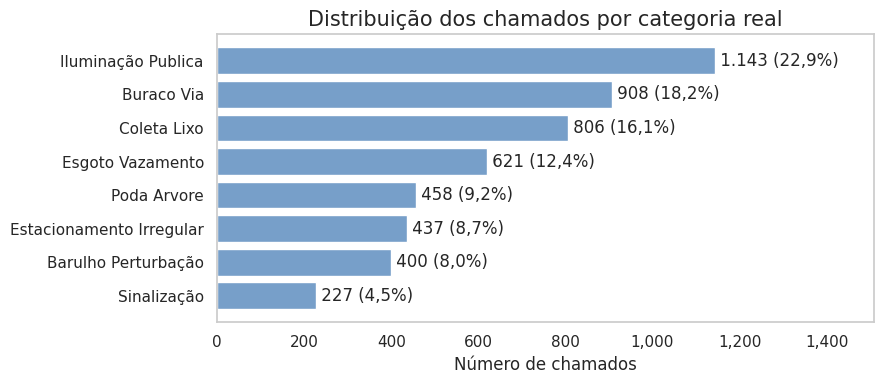

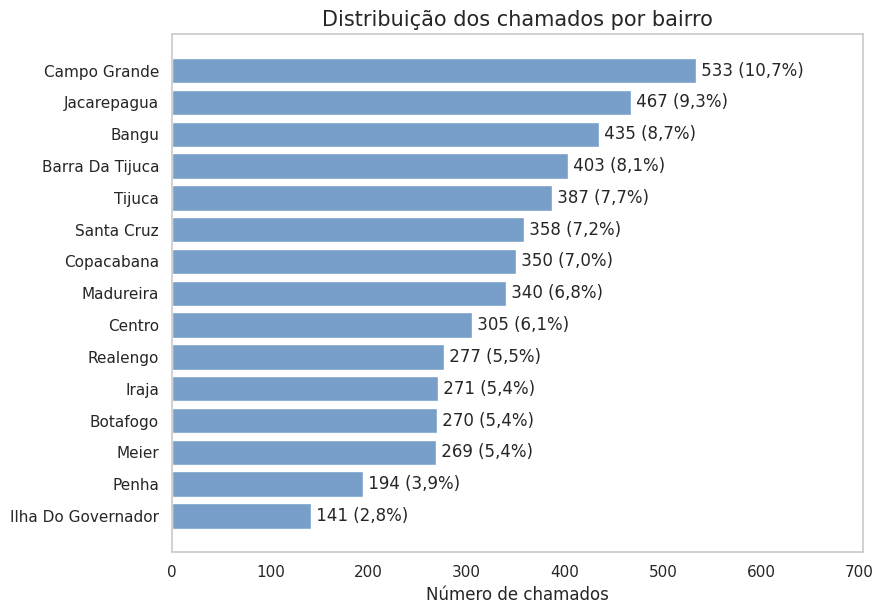

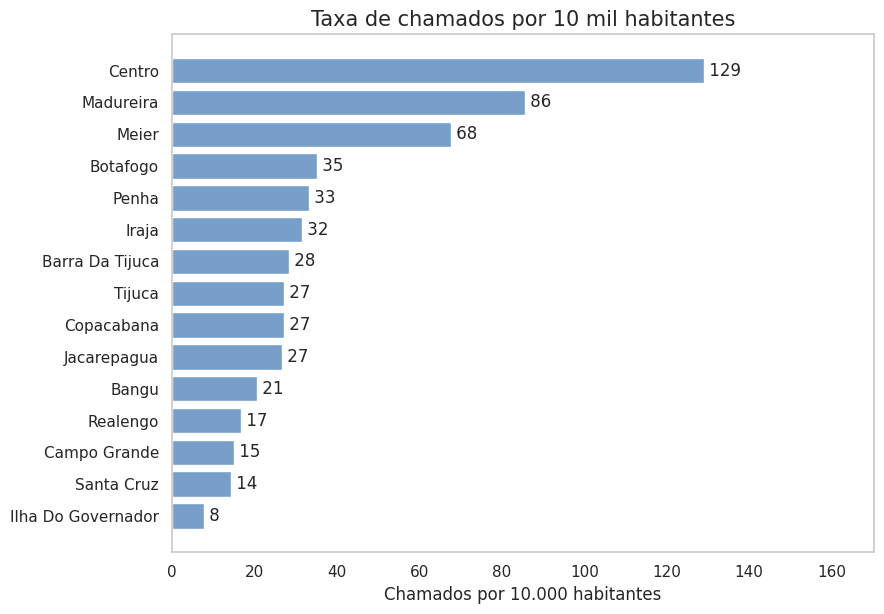

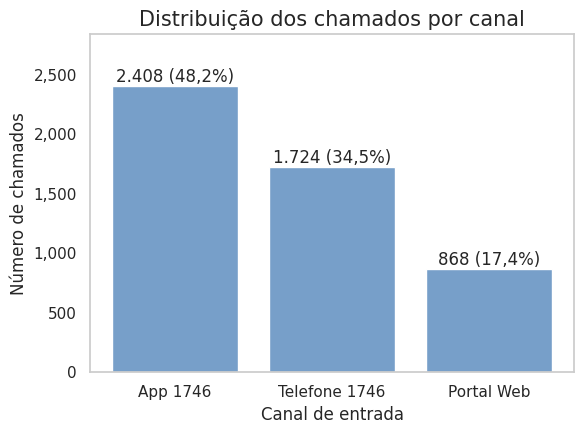

In [330]:
pop_bairros = pd.read_csv("../dados/censo2022.csv")
tabela_categorias = tabela_contagem_percentual(df, "categoria_real")
tabela_canais = tabela_contagem_percentual(df, "canal")
tabela_bairros = tabela_contagem_percentual(df, "bairro")
tabela_bairros_pop = (tabela_bairros.merge(pop_bairros[["bairro", "pop_bairro"]], on="bairro", how="left"))
tabela_bairros_pop["chamados_por_10k_hab"] = (tabela_bairros_pop["n"] / tabela_bairros_pop["pop_bairro"] * 10000)

plotar_barras_horizontais(
    tabela_categorias,"categoria_real","n",
    "Distribuição dos chamados por categoria real","Número de chamados",
    "02_barras_categorias_reais",
    coluna_percentual="percentual"
)

plotar_barras_horizontais(
    tabela_bairros,"bairro","n",
    "Distribuição dos chamados por bairro","Número de chamados",
    "02_barras_bairros",
    top_n=15,coluna_percentual="percentual"
)

plotar_barras_horizontais(
    tabela_bairros_pop,"bairro","chamados_por_10k_hab",
    "Taxa de chamados por 10 mil habitantes","Chamados por 10.000 habitantes",
    "02_barras_bairros_por_10mil_habitantes",
    top_n=15,coluna_percentual=None
)

plotar_barras_verticais(
    tabela_canais,"canal","n",
    "Distribuição dos chamados por canal","Canal de entrada","Número de chamados",
    "02_barras_canais",
    coluna_percentual="percentual"
)


#### 2.2 Série Temporal de Chamados

In [331]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

In [332]:
def _melhor_grau(x, y, grau_max=5):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    return min(
        range(1, grau_max + 1),
        key=lambda g: -cross_val_score(
            LinearRegression(),
            PolynomialFeatures(g, include_bias=False).fit_transform(x[:, None]),
            y, cv=kf, scoring="neg_mean_squared_error"
        ).mean())

def plotar_linha_temporal(tabela, coluna_data, coluna_valor, titulo, ylabel, nome_arquivo, curva="auto", grau_max=5):
    tabela = tabela.sort_values(coluna_data)
    x = np.arange(len(tabela))
    y = tabela[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(tabela[coluna_data], y, marker="o", label="Observado")

    if curva is not None:
        grau = _melhor_grau(x, y, grau_max) if curva == "auto" else curva
        X = PolynomialFeatures(grau, include_bias=False).fit_transform(x[:, None])
        y_pred = LinearRegression().fit(X, y).predict(X)
        ax.plot(tabela[coluna_data], y_pred, "--", linewidth=2, label=f"Tendência (grau {grau})")
        ax.legend()

    ax.set(title=titulo, xlabel="Período", ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_linhas_temporais_por_grupo(df, coluna_data, coluna_grupo,
                                    titulo, ylabel, nome_arquivo,freq="W", top_n=None):
    dados = df.copy()
    dados[coluna_data] = pd.to_datetime(dados[coluna_data])

    tabela = (dados.groupby([pd.Grouper(key=coluna_data, freq=freq), coluna_grupo])
        .size().reset_index(name="n_chamados"))

    if top_n is not None:
        grupos = (dados[coluna_grupo].value_counts().head(top_n).index)
        tabela = tabela[tabela[coluna_grupo].isin(grupos)]

    tabela_pivot = (tabela.pivot(index=coluna_data, columns=coluna_grupo, values="n_chamados")
        .fillna(0).sort_index())

    tabela_pivot.columns = [pretty_label(coluna) for coluna in tabela_pivot.columns]

    fig, ax = plt.subplots(figsize=(15, 5))
    for coluna in tabela_pivot.columns:
        ax.plot(tabela_pivot.index,tabela_pivot[coluna],marker="o",linewidth=1.8,label=coluna)

    ax.set_title(titulo)
    ax.set_xlabel("Período")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

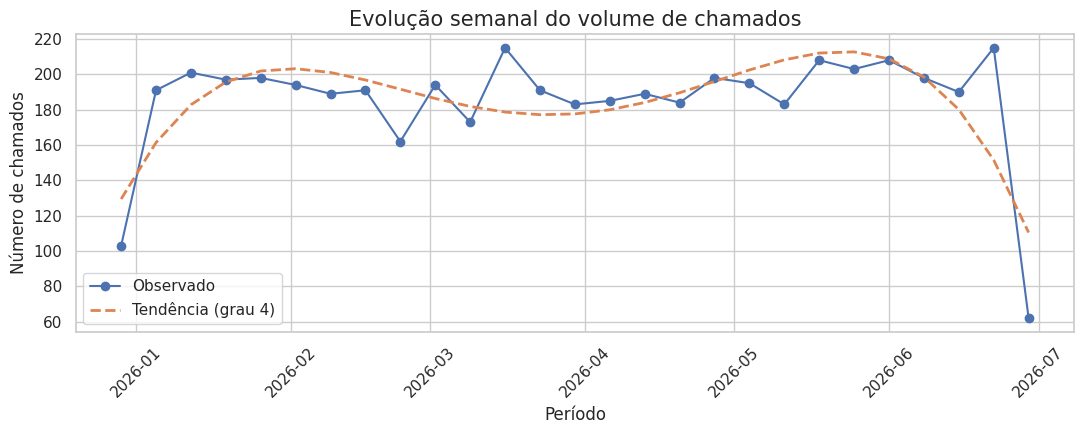

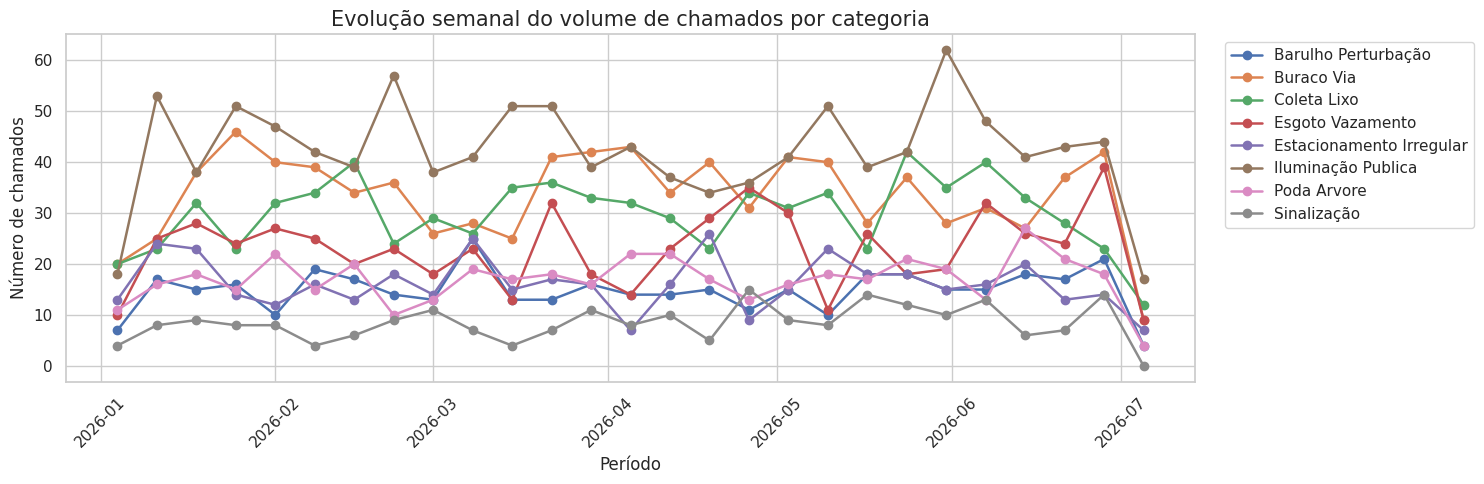

In [333]:
#tabela_temporal_mes = df.groupby("month").size().reset_index(name="n_chamados")
tabela_temporal_semana = df.groupby("week").size().reset_index(name="n_chamados")

plotar_linha_temporal(
    tabela_temporal_semana,
    "week",
    "n_chamados",
    "Evolução semanal do volume de chamados",
    "Número de chamados",
    "02_linha_volume_semanal"
)

plotar_linhas_temporais_por_grupo(
    df,
    "data_abertura",
    "categoria_real",
    "Evolução semanal do volume de chamados por categoria",
    "Número de chamados",
    "02_linha_volume_semanal_por_categoria",
    freq="W"
)

#### 2.3 Mapas por Bairros

In [334]:
import requests
from matplotlib.colors import Normalize
from shapely.geometry import Polygon

In [335]:
rio_bairro_url = "https://pgeo3.rio.rj.gov.br/arcgis/rest/services/Cartografia/Limites_administrativos/MapServer/4/query?where=1%3D1&outFields=nome,regiao_adm,codbairro_long&outSR=4326&f=json"
geo_json = requests.get(rio_bairro_url).json()
gdf_bairros = gpd.GeoDataFrame(
    ({
        "code": f["attributes"]["codbairro_long"],
        "regiao_adm": f["attributes"]["regiao_adm"].strip().lower(),
        "bairro": remove_accent(f["attributes"]["nome"].strip().lower()),
        "geometry": Polygon(f["geometry"]["rings"][0]),
    } for f in geo_json["features"]),
    geometry="geometry",
    crs="EPSG:4326",
)
gdf_bairros.head()

,code,regiao_adm,bairro,geometry
0,133,barra da tijuca,grumari,"POLYGON ((-43.50819 -23.03311, -43.50719 -23.0..."
1,137,realengo,jardim sulacap,"POLYGON ((-43.37541 -22.88962, -43.37542 -22.8..."
2,1,portuaria,saude,"POLYGON ((-43.18115 -22.89543, -43.18126 -22.8..."
3,84,madureira,vaz lobo,"POLYGON ((-43.32395 -22.85527, -43.32354 -22.8..."
4,91,ilha do governador,ribeira,"POLYGON ((-43.16461 -22.82115, -43.16459 -22.8..."


In [336]:
codes = {"ilha do governador": [91,92,93,94,95,96,97,98,99,100,101,102,103,104]} # bairros da ilha do governador
var = "regiao_adm" # ou "regiao_adm"
if var == "bairro":
    code_to_bairro = {c: b for b, lst in codes.items() for c in lst}
    gdf_bairros["bairro"] = gdf_bairros["code"].map(code_to_bairro).fillna(gdf_bairros["bairro"])

In [337]:
def juntar_chamados_com_malha(df, gdf, var="bairro"):
    mapa = gdf.merge(df.groupby("bairro").size().rename("n_chamados"),
            left_on=var, right_index=True, how="left").fillna({"n_chamados": 0})
    return mapa

def plotar_mapa_bairros(mapa, titulo, nome_arquivo):
    fig, ax = plt.subplots(figsize=(7,4))
    mapa.plot(
        column="n_chamados",
        cmap="Reds",
        linewidth=0.45,
        edgecolor="0.4",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Sem correspondência"}
    )
    ax.set_title(titulo)
    ax.set_axis_off()
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_evolucao_mensal_bairros(df, gdf, title, nome_arquivo):
    periodos = sorted(df["month"].dropna().unique())
    ncols = 3
    nrows = math.ceil(len(periodos) / ncols)
    contagens_global = df.groupby(["month", "bairro"]).size().reset_index(name="n_chamados")
    vmax = contagens_global["n_chamados"].max()
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, periodo in enumerate(periodos):
        dados_periodo = df[df["month"] == periodo]
        mapa_periodo = juntar_chamados_com_malha(dados_periodo, gdf, var)
        mapa_periodo.plot(
            column="n_chamados",
            cmap="Reds",
            linewidth=0.45,
            edgecolor="0.45",
            vmin=0,
            vmax=vmax,
            ax=axes[i]
        )
        axes[i].set_title(pd.to_datetime(periodo).strftime("%d/%m/%y"))
        axes[i].set_axis_off()
    for j in range(len(periodos), len(axes)):
        axes[j].set_visible(False)
    normalizador = Normalize(vmin=0, vmax=vmax)
    mapeavel = cm.ScalarMappable(norm=normalizador, cmap="Reds")
    mapeavel.set_array([])
    fig.colorbar(mapeavel, ax=axes[:len(periodos)], cax=fig.add_axes([0.99, 0.20, 0.018, 0.60]))
    fig.suptitle(title, y=0.93, fontsize=15)
    save_figure(fig, nome_arquivo)
    plt.show()

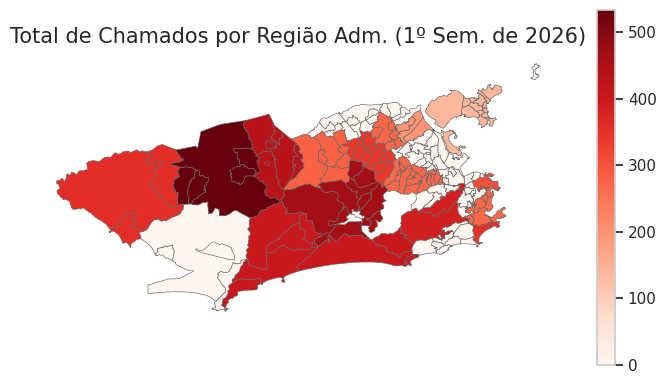

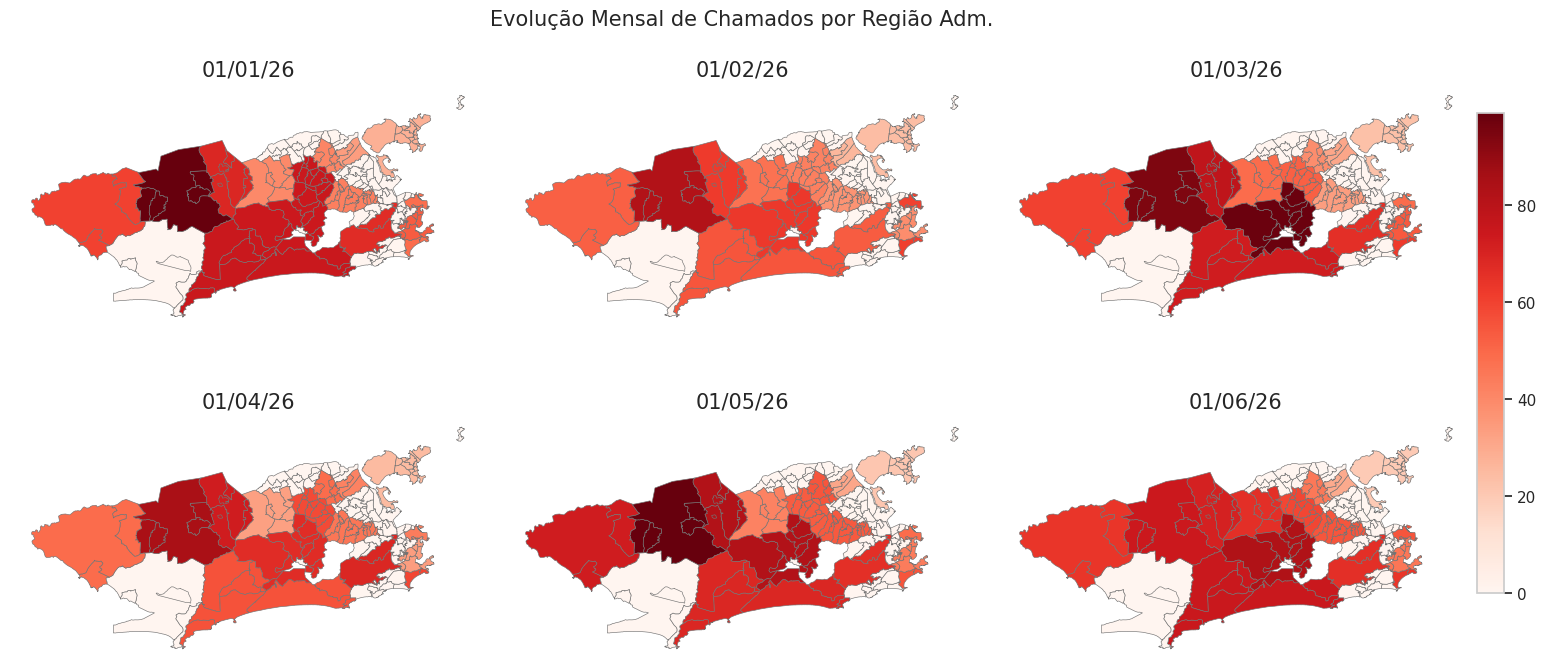

In [338]:
mapa_bairros = juntar_chamados_com_malha(df, gdf_bairros,var)
name = "Bairro" if var == "bairro" else "Região Adm."

plotar_mapa_bairros(
    mapa_bairros,
    f"Total de Chamados por {name} (1º Sem. de 2026)",
    "02_mapa_volume_total_bairros"
)

plotar_evolucao_mensal_bairros(
    df,
    gdf_bairros,
    f"Evolução Mensal de Chamados por {name}",
    "02_mapa_evolucao_mensal_bairros",
)

### 3. Composição das Categorias por Subgrupo

In [339]:
def aplicar_rotulos_eixo(eixo):
    return [pretty_label(valor) for valor in eixo]

def calcular_percentuais(tabela, percentual_por="linha"):
    dados = tabela.copy().astype(float)
    if percentual_por == "linha":
        return dados.div(dados.sum(axis=1), axis=0) * 100
    if percentual_por == "coluna":
        return dados.div(dados.sum(axis=0), axis=1) * 100
    if percentual_por == "total":
        return dados / dados.values.sum() * 100
    raise ValueError("percentual_por deve ser 'linha', 'coluna' ou 'total'")

def plotar_heatmap(tabela, titulo, xlabel, ylabel, nome_arquivo, cmap="Blues", rotation=45, 
            formato_valor=".0f", percentual_por="linha",fontsize_valor=12, fontsize_percentual=9, mostrar_porcentagem=True):
    dados_abs = tabela.copy()
    dados_pct = calcular_percentuais(dados_abs, percentual_por=percentual_por)

    dados_abs.index = aplicar_rotulos_eixo(dados_abs.index)
    dados_abs.columns = aplicar_rotulos_eixo(dados_abs.columns)
    dados_pct.index = dados_abs.index
    dados_pct.columns = dados_abs.columns

    fig, ax = plt.subplots(figsize=(max(9, 1.15 * dados_abs.shape[1]),max(5, 0.85 * dados_abs.shape[0])))
    sns.heatmap(dados_abs, annot=False, cmap=cmap, linewidths=0.5, ax=ax, cbar=True, square=True)
    limite_cor_texto = dados_abs.to_numpy().max() * 0.55

    for i in range(dados_abs.shape[0]):
        for j in range(dados_abs.shape[1]):
            valor = dados_abs.iloc[i, j]
            cor = "white" if valor >= limite_cor_texto else "#222222"
            if mostrar_porcentagem:
                percentual = dados_pct.iloc[i, j]
                ax.text(j + 0.5, i + 0.65, f"({percentual:.1f}%)",
                    ha="center", va="center", fontsize=fontsize_percentual, color=cor)

            ax.text(j + 0.5, i + 0.42, f"{valor:{formato_valor}}",
                    ha="center", va="center", fontsize=fontsize_valor, color=cor)

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=rotation, ha="right")
    plt.yticks(rotation=0)

    fig.tight_layout()
    save_figure(fig, nome_arquivo)

### 3.1 Heatmap de Categorias por Canal e Bairro

In [340]:
canal_categoria_abs = pd.crosstab(df["canal"], df["categoria_real"])
bairro_categoria_abs = pd.crosstab(df["bairro"], df["categoria_real"])

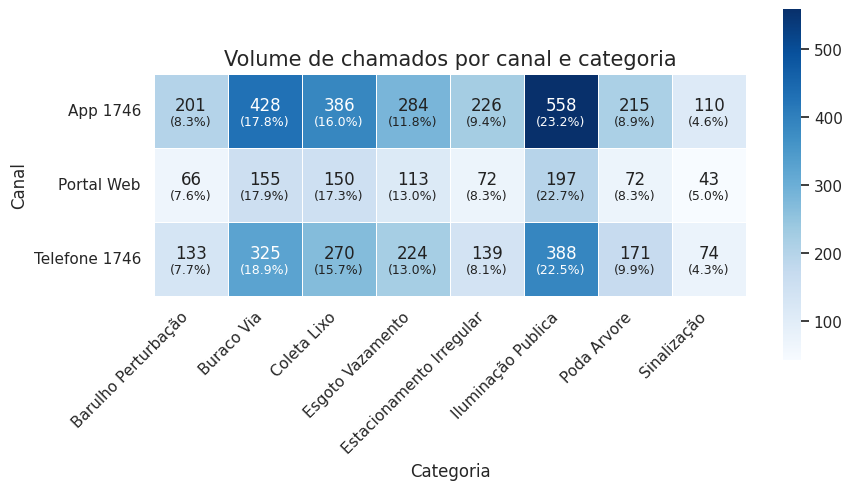

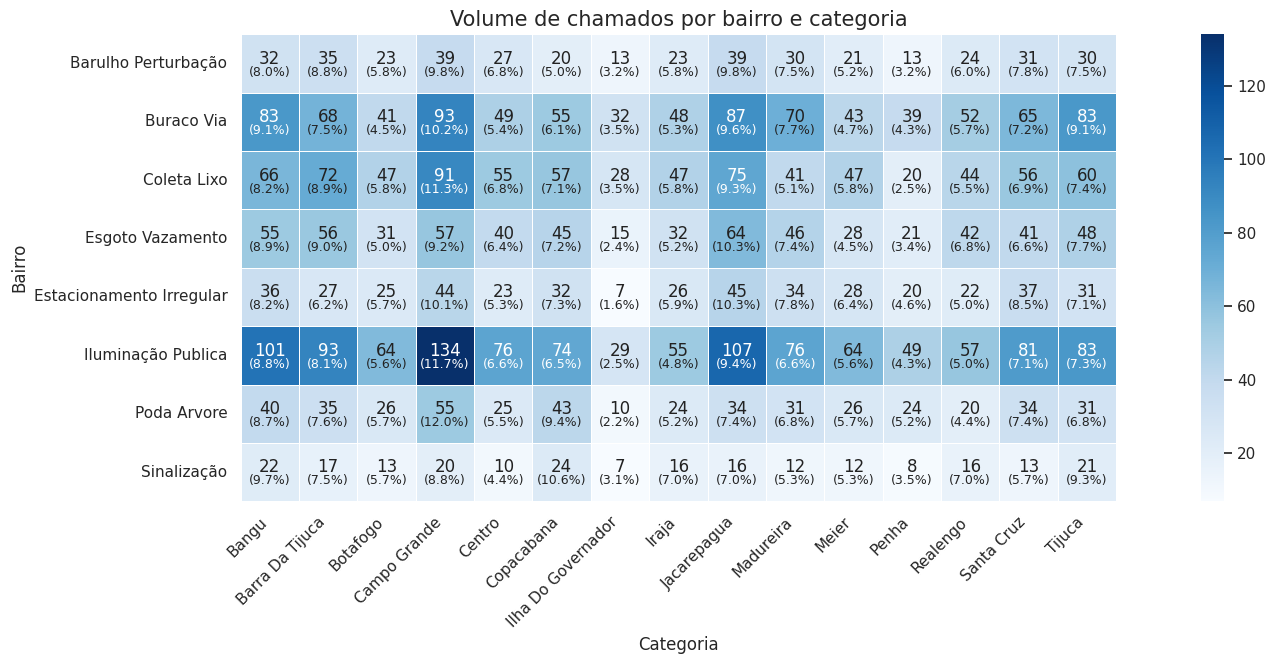

In [341]:
plotar_heatmap(
    canal_categoria_abs,
    "Volume de chamados por canal e categoria",
    "Categoria","Canal",
    "03_heatmap_categoria_canal_absoluto",
    cmap="Blues"
)

plotar_heatmap(
    bairro_categoria_abs.T,
    "Volume de chamados por bairro e categoria",
    "Categoria","Bairro",
    "03_heatmap_categoria_bairro_absoluto",
    cmap="Blues"
)



### 3.1 Barras Empilhadas do Percentual de Categorias e Canais por Mês

In [353]:
def plotar_barras_empilhadas_percentuais(tabela, titulo, xlabel, ylabel, nome_arquivo, formatar_datas=False):
    dados = tabela.copy()
    dados.index = pd.to_datetime(dados.index).strftime("%m/%y") if formatar_datas else aplicar_rotulos_eixo(dados.index)
    dados.columns = aplicar_rotulos_eixo(dados.columns)
    
    ax = dados.plot(kind="bar", stacked=True, figsize=(11, 5.5))
    ax.set(title=titulo, xlabel=xlabel, ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=0)

    fig = ax.get_figure()
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

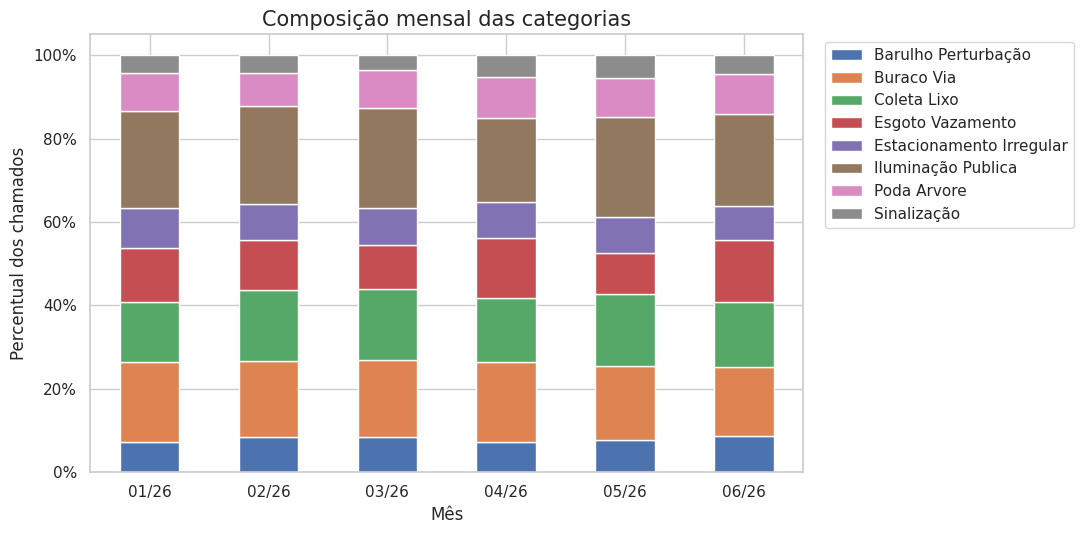

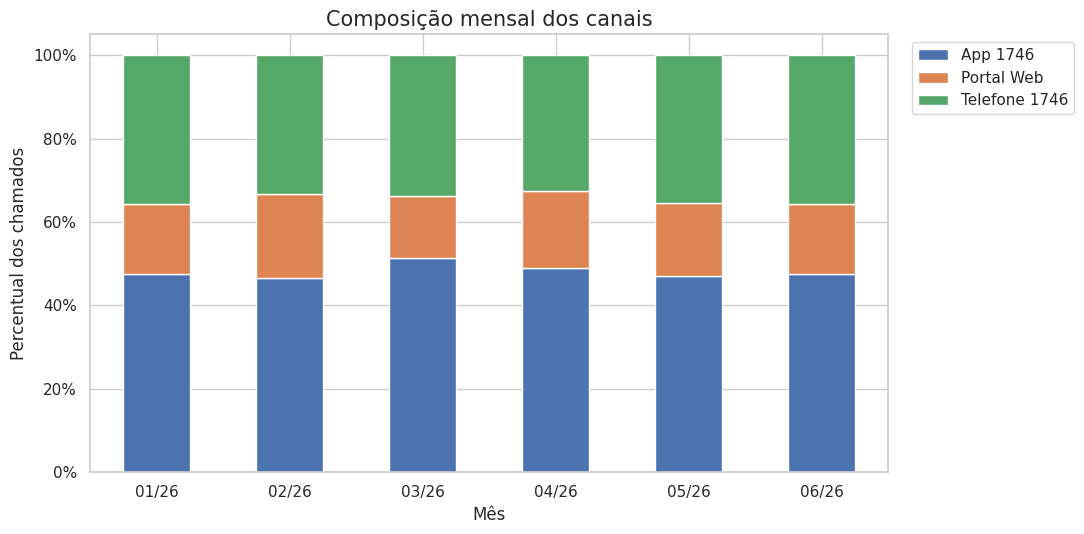

In [354]:
mes_categoria_pct_por_mes = pd.crosstab(df["month"], df["categoria_real"], normalize="index") * 100
mes_canal_pct_por_mes = pd.crosstab(df["month"], df["canal"], normalize="index") * 100

plotar_barras_empilhadas_percentuais(
    mes_categoria_pct_por_mes,
    "Composição mensal das categorias",
    "Mês",
    "Percentual dos chamados",
    "03_barras_empilhadas_categoria_por_mes",
    True
)

plotar_barras_empilhadas_percentuais(
    mes_canal_pct_por_mes,
    "Composição mensal dos canais",
    "Mês",
    "Percentual dos chamados",
    "03_barras_empilhadas_canal_por_mes",
    True
)

### 4. Características dos Textos e Análise Lexical

In [344]:
from unidecode import unidecode

STOPWORDS_PT = {
    "a", "à", "às", "ao", "aos", "aquela", "aquelas", "aquele", "aqueles", "aquilo",
    "as", "até", "com", "como", "da", "das", "de", "dela", "delas", "dele", "deles",
    "depois", "do", "dos", "e", "é", "ela", "elas", "ele", "eles", "em", "entre",
    "era", "eram", "essa", "essas", "esse", "esses", "esta", "está", "estão", "estas",
    "este", "estes", "eu", "foi", "foram", "há", "isso", "isto", "já", "lhe", "lhes",
    "mais", "mas", "me", "mesmo", "meu", "meus", "minha", "minhas", "muito", "na",
    "não", "nas", "nem", "no", "nos", "nós", "nossa", "nossas", "nosso", "nossos",
    "num", "numa", "o", "os", "ou", "para", "pela", "pelas", "pelo", "pelos",
    "por", "qual", "quando", "que", "quem", "se", "sem", "ser", "seu", "seus",
    "sua", "suas", "também", "tem", "têm", "tendo", "tenho", "ter", "teu", "teus",
    "tua", "tuas", "um", "uma", "umas", "uns", "vai", "vão", "você", "vocês",
    "favor", "solicito", "solicitar", "pedido", "chamado", "problema", "local",
    "rua", "avenida", "av", "r", "bairro", "próximo", "proximo", "frente"
}

In [345]:
def limpar_texto_lexical(texto):
    texto = "" if pd.isna(texto) else str(texto)
    texto = texto.lower()
    texto = unidecode(texto)
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = [token for token in texto.split() if token not in STOPWORDS_PT and len(token) >= 3]
    return " ".join(tokens)

def proporcao_caixa_alta(texto):
    texto = "" if pd.isna(texto) else str(texto)
    letras = re.findall(r"[A-Za-zÀ-ÿ]", texto)
    if len(letras) == 0:
        return 0
    maiusculas = [letra for letra in letras if letra.isupper()]
    return len(maiusculas) / len(letras)

def contar_pontuacao(texto):
    texto = "" if pd.isna(texto) else str(texto)
    return len(re.findall(r"[!?.,;:]", texto))

def contar_digitos(texto):
    texto = "" if pd.isna(texto) else str(texto)
    return len(re.findall(r"\d", texto))

df["texto_lexical"] = df["texto"].map(limpar_texto_lexical)
df["n_tokens_lexicais"] = df["texto_lexical"].str.split().str.len()
df["proporcao_caixa_alta"] = df["texto"].map(proporcao_caixa_alta)
df["n_pontuacao"] = df["texto"].map(contar_pontuacao)
df["texto_sem_tokens_uteis"] = df["n_tokens_lexicais"] == 0

#### 4.1 Estatísticas Qualitativas dos Textos 

In [346]:
variaveis_texto = [
    "tamanho_texto_caracteres",
    "tamanho_texto_palavras",
    "n_tokens_lexicais",
    "proporcao_caixa_alta",
]

indicadores_texto = pd.DataFrame({
    "indicador": [
        "Textos com até 5 palavras",
        "Textos sem tokens úteis após limpeza",
        "Textos com mais de 30% de letras maiúsculas"
    ],
    "n": [
        int(df["bool_texto_curto"].sum()),
        int(df["texto_sem_tokens_uteis"].sum()),
        int((df["proporcao_caixa_alta"] > 0.30).sum())
    ]
})

indicadores_texto["percentual"] = 100 * indicadores_texto["n"] / len(df)

display(indicadores_texto)

,indicador,n,percentual
0,Textos com até 5 palavras,120,2.4
1,Textos sem tokens úteis após limpeza,0,0.0
2,Textos com mais de 30% de letras maiúsculas,0,0.0


#### 4.2 Estatísticas Descritvias dos Textos

In [347]:
def gerar_estatisticas_texto(df, coluna_texto="texto_limpo", coluna_categoria="categoria_real"):
    dados = (df.copy().assign(
            texto=lambda x: x[coluna_texto].fillna("").astype(str),
            comprimento_caracteres=lambda x: x["texto"].str.len(),
            numero_palavras=lambda x: x["texto"].str.split().str.len()))

    estatisticas_gerais = (
        dados[["comprimento_caracteres", "numero_palavras"]]
        .agg(["mean", "median", "std", "min", "max"])
        .T
        .rename(index={
            "comprimento_caracteres": "Comprimento (caracteres)",
            "numero_palavras": "Palavras"},
        columns={
            "mean": "Média",
            "median": "Mediana",
            "std": "Desvio Padrão",
            "min": "Mín",
            "max": "Máx"})
        .reset_index(names="Métrica").round(2))

    estatisticas_por_categoria = (
        dados.groupby(coluna_categoria)["comprimento_caracteres"]
        .agg(["mean", "median", "std", "min", "max"])
        .rename(columns={
            "mean": "Média",
            "median": "Mediana",
            "std": "Desvio Padrão",
            "min": "Mín",
            "max": "Máx"
        })
        .sort_values("Média", ascending=False).round(2))
    return estatisticas_gerais, estatisticas_por_categoria

estatisticas_gerais_texto, estatisticas_categoria_texto = gerar_estatisticas_texto(df)
display(estatisticas_gerais_texto)
display(estatisticas_categoria_texto)

,Métrica,Média,Mediana,Desvio Padrão,Mín,Máx
0,Comprimento (caracteres),128.25,156.0,57.12,24.0,199.0
1,Palavras,23.26,28.0,10.56,4.0,39.0


,Média,Mediana,Desvio Padrão,Mín,Máx
categoria_real,,,,,
esgoto_vazamento,134.63,161.0,56.06,29,199
poda_arvore,131.41,160.0,59.17,27,199
iluminacao_publica,129.98,160.0,59.55,28,193
buraco_via,127.47,154.0,58.88,24,197
estacionamento_irregular,127.00,150.0,53.66,29,192
coleta_lixo,125.45,156.0,54.59,27,178
sinalizacao,124.27,153.0,53.98,31,180
barulho_perturbacao,120.76,147.0,54.52,30,191


#### 4.3 Distribuição do Tamanho dos Textos

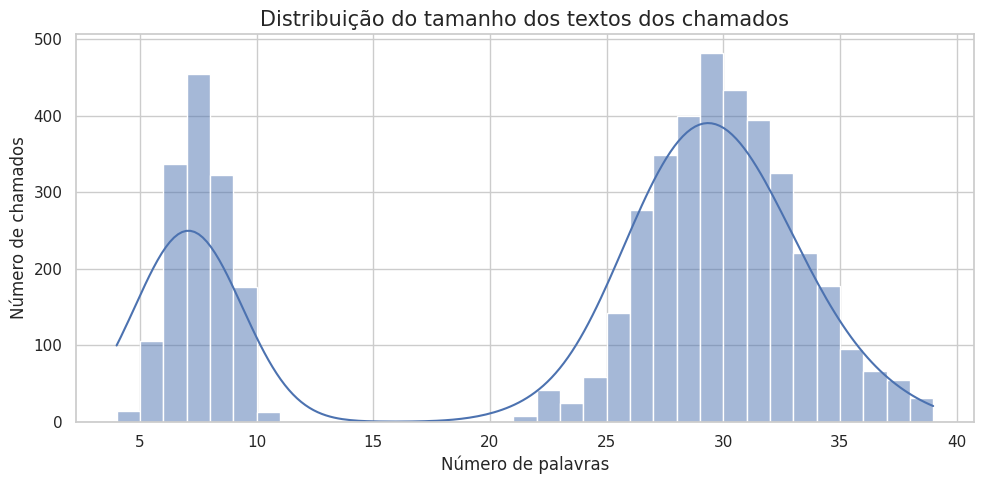

In [348]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["tamanho_texto_palavras"], bins=35, kde=True, ax=ax)
ax.set_title("Distribuição do tamanho dos textos dos chamados")
ax.set_xlabel("Número de palavras")
ax.set_ylabel("Número de chamados")
save_figure(fig, "04_histograma_tamanho_texto_palavras.png")
plt.show()

#### 4.4 Bigramas e Trigramas mais Frequentes

In [349]:
def obter_frequencias_ngrams(textos, ngram_range=(1, 1), max_features=30, min_df=2):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_df
    )
    matriz = vectorizer.fit_transform(textos)
    frequencias = np.asarray(matriz.sum(axis=0)).ravel()
    termos = vectorizer.get_feature_names_out()
    tabela = pd.DataFrame({"termo": termos, "frequencia": frequencias})
    return tabela.sort_values("frequencia", ascending=False).reset_index(drop=True)

def plotar_top_termos(tabela, titulo, nome_arquivo, top_n=25):
    dados = tabela.head(top_n).sort_values("frequencia", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.34 * len(dados))))
    ax.barh(dados["termo"], dados["frequencia"])
    ax.set_title(titulo)
    ax.set_xlabel("Frequência")
    ax.set_ylabel("")
    for i, valor in enumerate(dados["frequencia"]):
        ax.text(valor, i, f" {int(valor)}", va="center")
    save_figure(fig, nome_arquivo)
    plt.show()

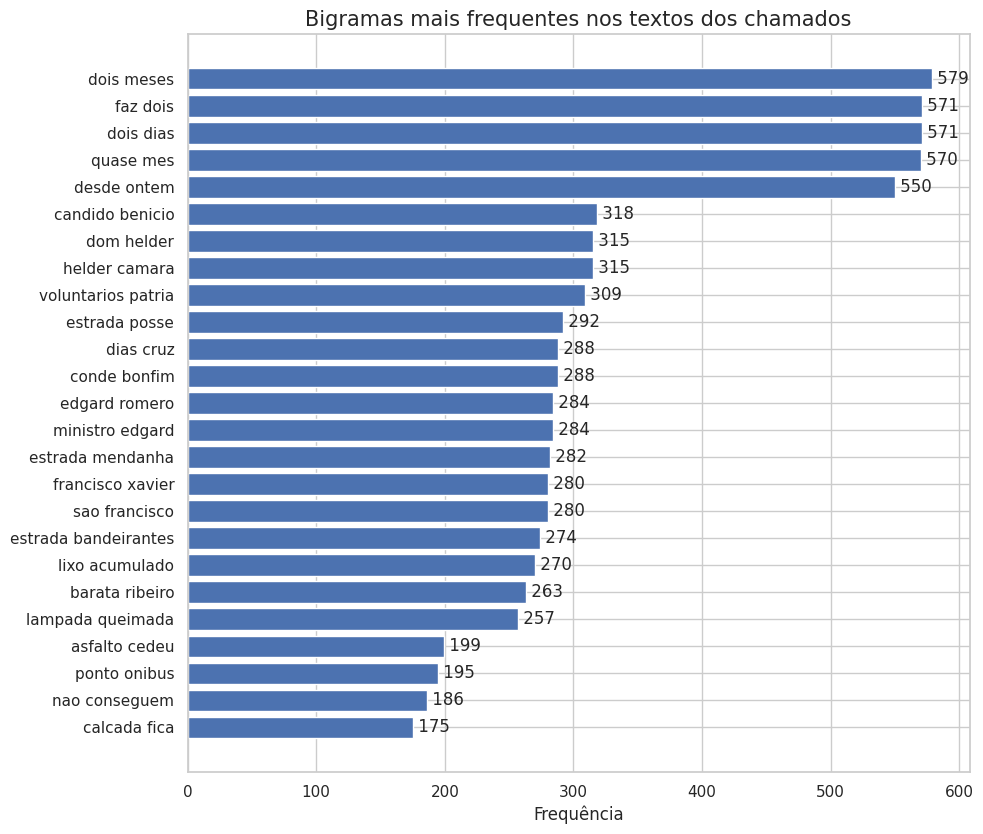

In [350]:
textos_lexicais = df.loc[df["texto_lexical"].str.len() > 0, "texto_lexical"]
frequencia_bigramas = obter_frequencias_ngrams(
    textos_lexicais,
    ngram_range=(2, 2),
    max_features=40,
    min_df=2
)

plotar_top_termos(
    frequencia_bigramas,
    "Bigramas mais frequentes nos textos dos chamados",
    "04_bigramas_mais_frequentes.png",
    top_n=25
)

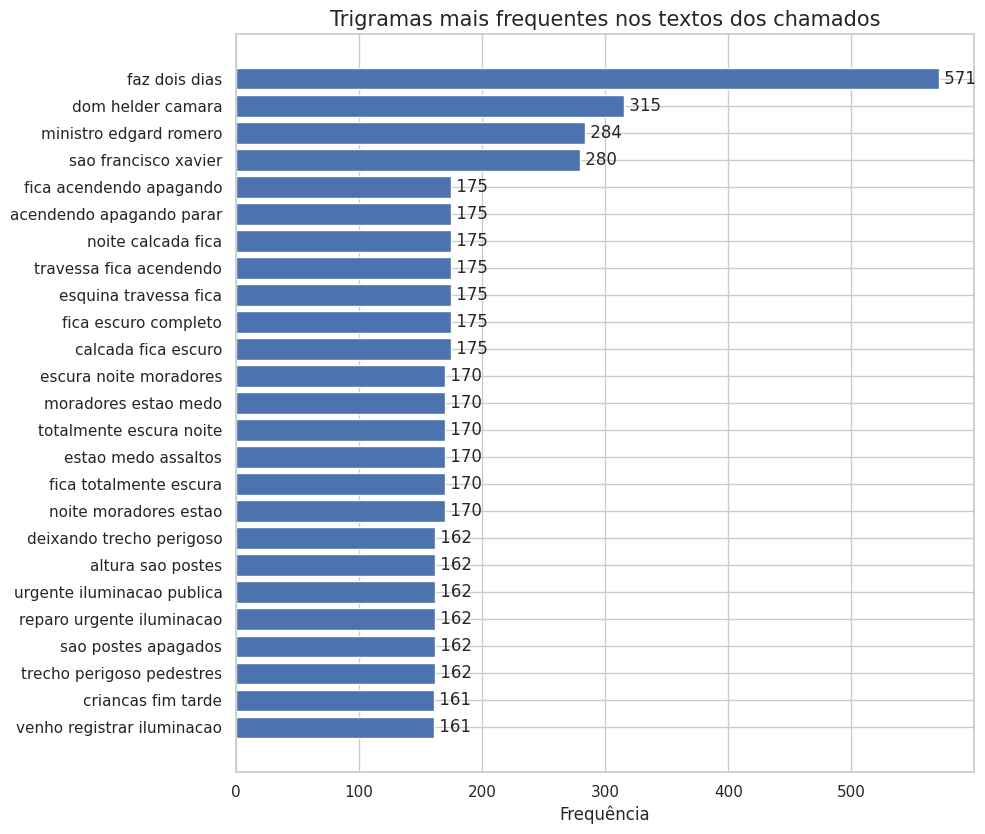

In [351]:
frequencia_trigramas = obter_frequencias_ngrams(textos_lexicais, ngram_range=(3, 3), max_features=40, min_df=2)

plotar_top_termos(
    frequencia_trigramas,
    "Trigramas mais frequentes nos textos dos chamados",
    "04_trigramas_mais_frequentes.png",
    top_n=25
)

#### 4.5 Matriz de Similaridade das Categorias

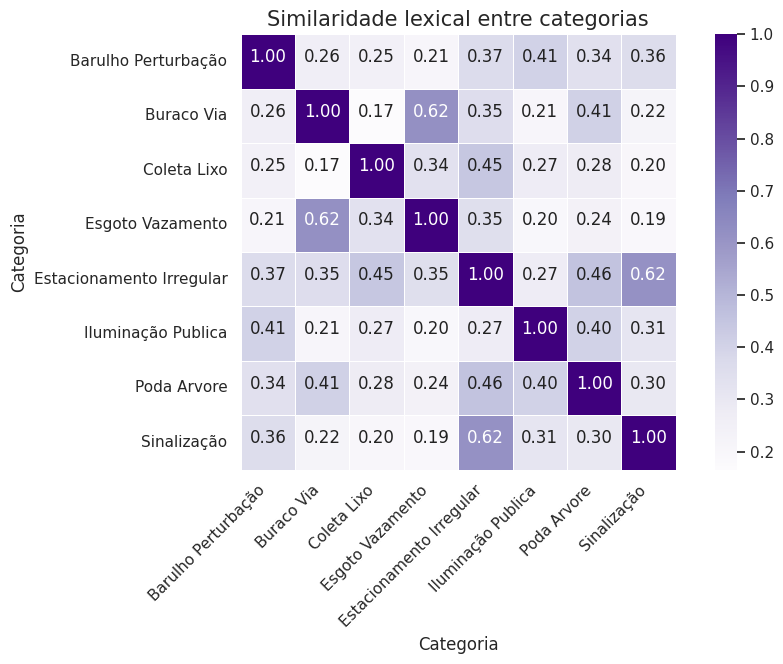

In [352]:
from sklearn.metrics.pairwise import cosine_similarity

def matriz_similaridade_categorias(df, coluna_categoria="categoria_real", coluna_texto="texto_lexical", ngram_range=(1, 2), min_df=2):
    textos_categoria = (df.groupby(coluna_categoria)[coluna_texto].apply(lambda textos: " ".join(textos.dropna().astype(str))).reset_index())
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_features=2500)
    matriz = vectorizer.fit_transform(textos_categoria[coluna_texto])
    similaridade = cosine_similarity(matriz)
    tabela = pd.DataFrame(
        similaridade,
        index=textos_categoria[coluna_categoria],
        columns=textos_categoria[coluna_categoria]
    )
    return tabela

similaridade_categorias = matriz_similaridade_categorias(df)
plotar_heatmap(similaridade_categorias,
    "Similaridade lexical entre categorias","Categoria","Categoria",
    "04_heatmap_similaridade_lexical_categorias",
    formato_valor=".2f",cmap="Purples",mostrar_porcentagem=False
)